In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error

C:\ProgramData\Anaconda4\lib\site-packages\sklearn\ensemble\weight_boosting.py:29: DeprecationWarning: numpy.core.umath_tests is an internal NumPy module and should not be imported. It will be removed in a future NumPy release.
  from numpy.core.umath_tests import inner1d


In [2]:
df=pd.read_excel("Donnees_Vario2.xlsx")

In [3]:
df.head()

,h(en km),ɣ (h)
0,1.00,9.42
1,1.40,9.60
2,2.00,12.18
3,2.83,12.90
4,3.00,14.18


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 2 columns):
h(en km)     29 non-null float64
ɣ (h)        29 non-null float64
dtypes: float64(2)
memory usage: 544.0 bytes


In [5]:
df.describe()

,h(en km),ɣ (h)
count,29.000000,29.000000
mean,29.096897,23.590345
std,31.376320,8.109741
min,1.000000,9.420000
25%,5.000000,17.120000
50%,10.000000,25.200000
75%,50.000000,30.300000
max,100.000000,39.700000


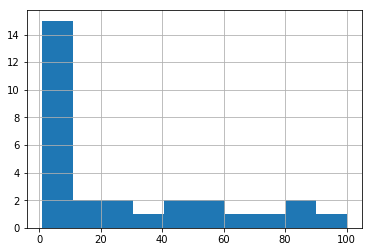

In [6]:
df['h(en km) '].hist()

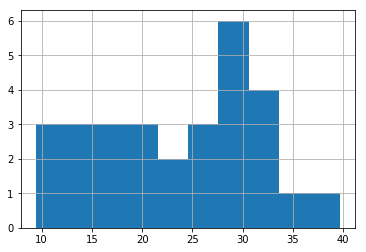

In [7]:
df['ɣ (h) '].hist()

In [8]:
df.corr()


,h(en km),ɣ (h)
h(en km),1.000000,0.773357
ɣ (h),0.773357,1.000000


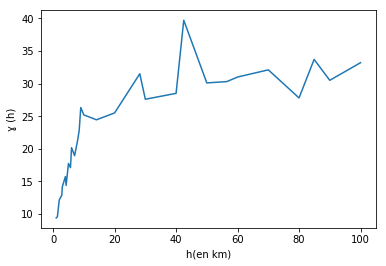

In [9]:
plt.plot(df['h(en km) '],df['ɣ (h) '])
plt.xlabel("h(en km)")
plt.ylabel("ɣ (h)")
plt.show()


In [10]:
X=df[['h(en km) ']]
y=df['ɣ (h) ']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [11]:
rf_model=RandomForestRegressor(n_estimators=100,random_state=42)
#What if you use GridSearch ? For models 
rf_model.fit(X_train,y_train)

RandomForestRegressor(bootstrap=True, criterion='mse', max_depth=None,
           max_features='auto', max_leaf_nodes=None,
           min_impurity_decrease=0.0, min_impurity_split=None,
           min_samples_leaf=1, min_samples_split=2,
           min_weight_fraction_leaf=0.0, n_estimators=100, n_jobs=1,
           oob_score=False, random_state=42, verbose=0, warm_start=False)

In [12]:
y_pred_rf=rf_model.predict(X_test)

In [13]:
def evaluate(y_true,y_pred,name):
    mse=mean_squared_error(y_true,y_pred)
    rmse=np.sqrt(mean_squared_error(y_true,y_pred))
    mae=mean_absolute_error(y_true,y_pred)
    r2=r2_score(y_true,y_pred)
    print(f"{name}->RMSE:{rmse:.3f},MSE:{mse:.3f},MAE:{mae:.3f},R2:{r2:.3f}")

In [14]:
evaluate(y_test,y_pred_rf,"Random Forest Regressor")

Random Forest Regressor->RMSE:1.332,MSE:1.773,MAE:1.040,R2:0.927


In [ ]:
pd.read_excel("Correction_Donnees_Vario.xlsx") #Importing the second excel file with Power and Logarithmic models

In [15]:
#Random Forest Regressor->RMSE:1.331,MSE:1.771,MAE:1.054,R2:0.927 (n=200)
#Random Forest Regressor->RMSE:1.332,MSE:1.773,MAE:1.040,R2:0.927 (n=100)
# We got a MSE's reduction of 85,25% between RFR model (from this notebook) and Power model (from the 2nd excel file)


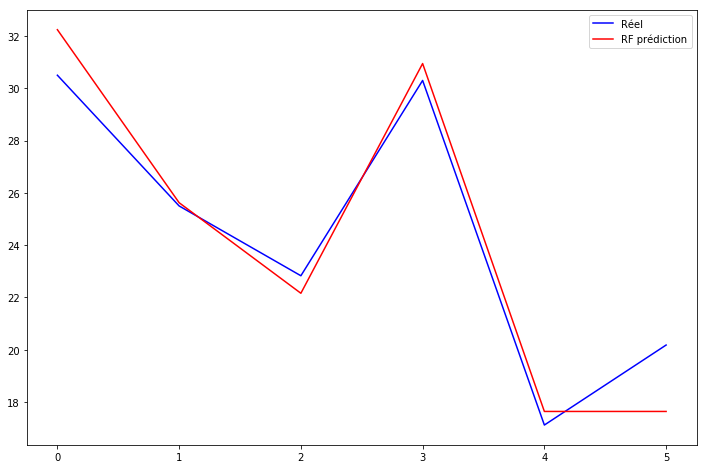

In [16]:
plt.figure(figsize=(12,8))
indices=np.arange(len(y_test))
plt.plot(indices,y_test.values,label="Réel",color='blue')
plt.plot(indices,y_pred_rf,label="RF prédiction",color='red')
plt.legend()
plt.show()
